In [24]:
import sys
sys.path.insert(0, "..") # add parent CNODE package to sys.path

import numpy as np
import matplotlib.pyplot as plt
from src.data.catechol_loader import load_single_solvent_data, spange_featurize_input_df, train_test_split
from src.models.nn_pyomo_base import NeuralODEPyomo

## 1. Create dataset of single solvent ramps 

/var/folders/r1/wwc0bs812_n_bzhhn7l3nxvc0000gp/T/ipykernel_8977/690649551.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("nipy_spectral", len(unique_solvents))


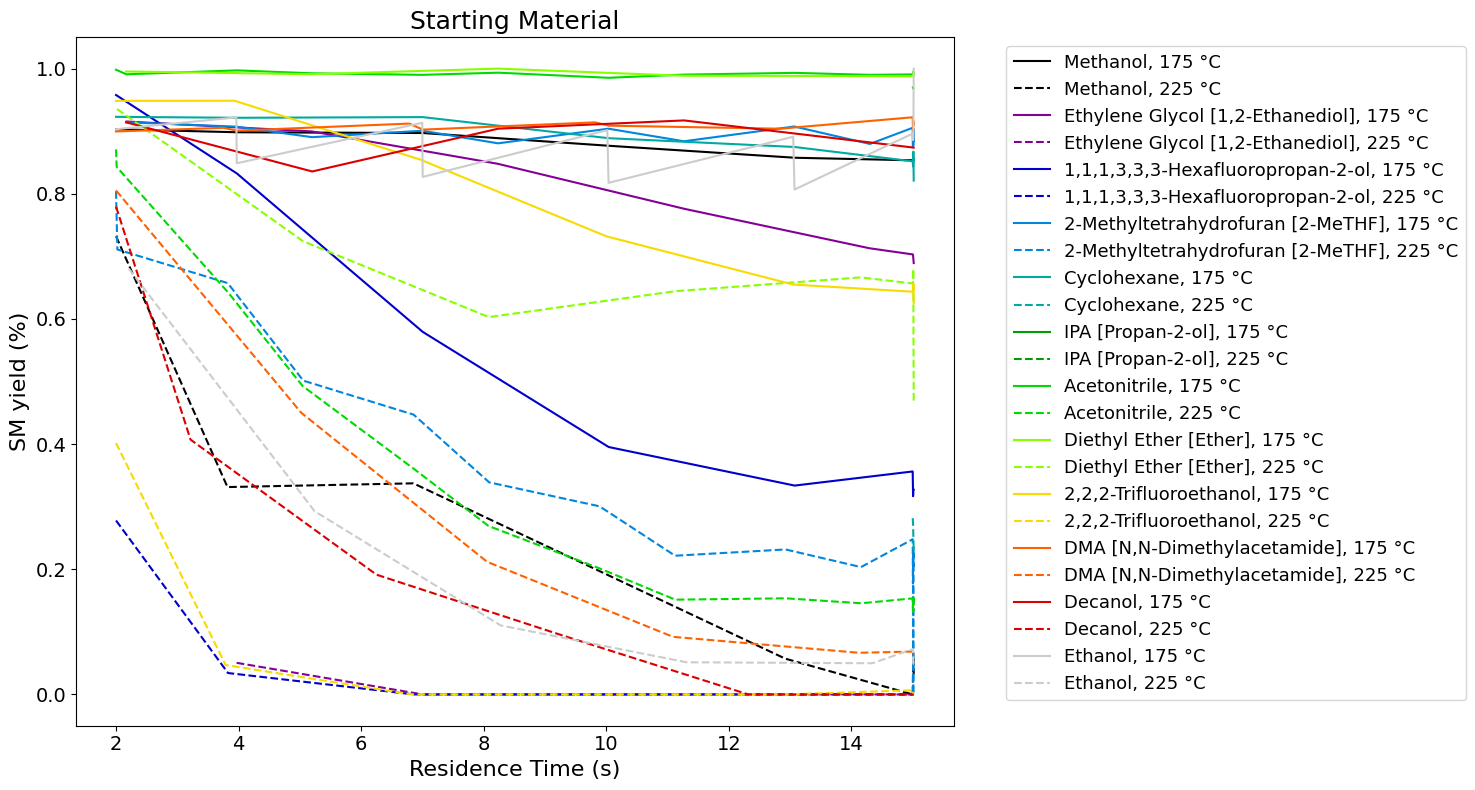

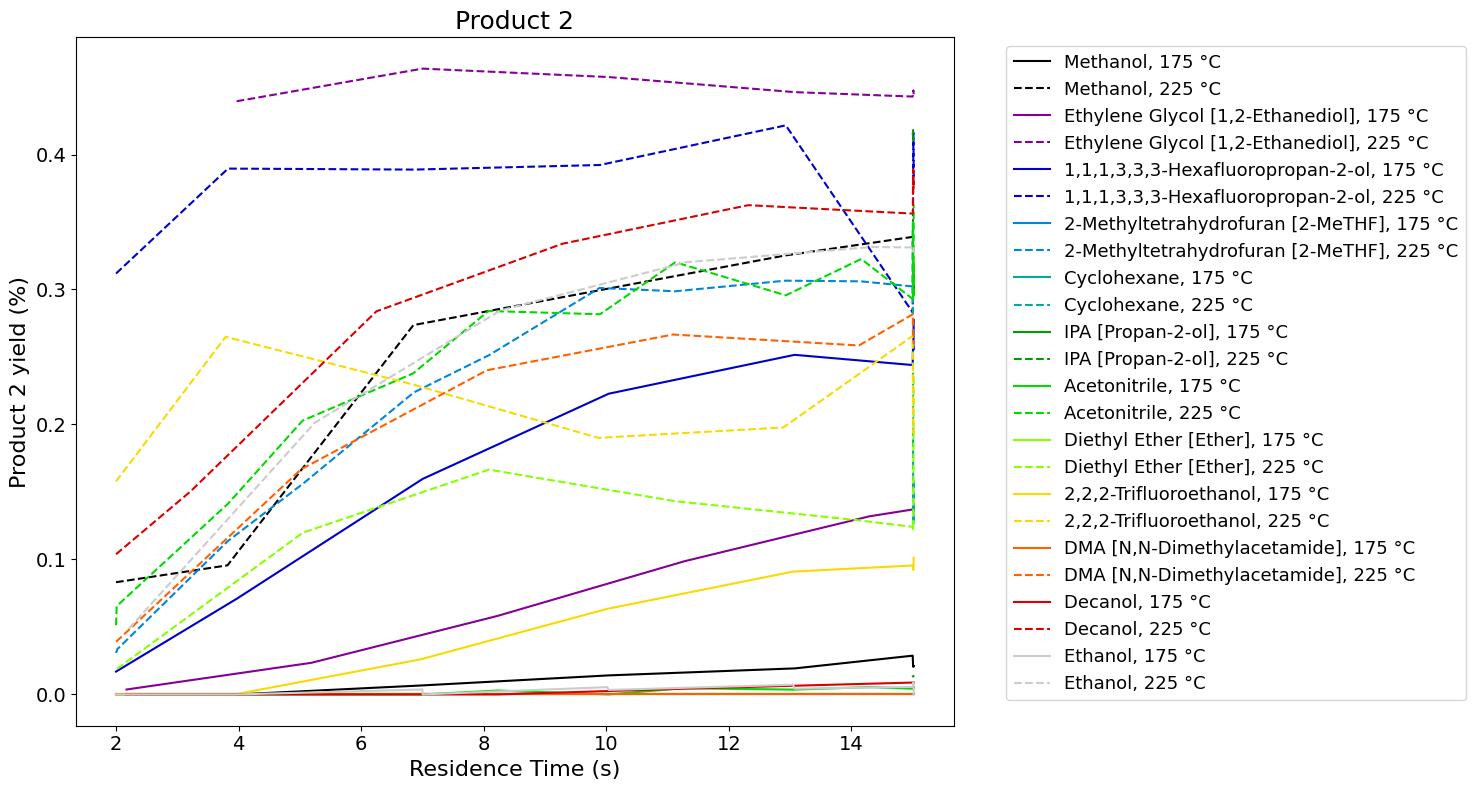

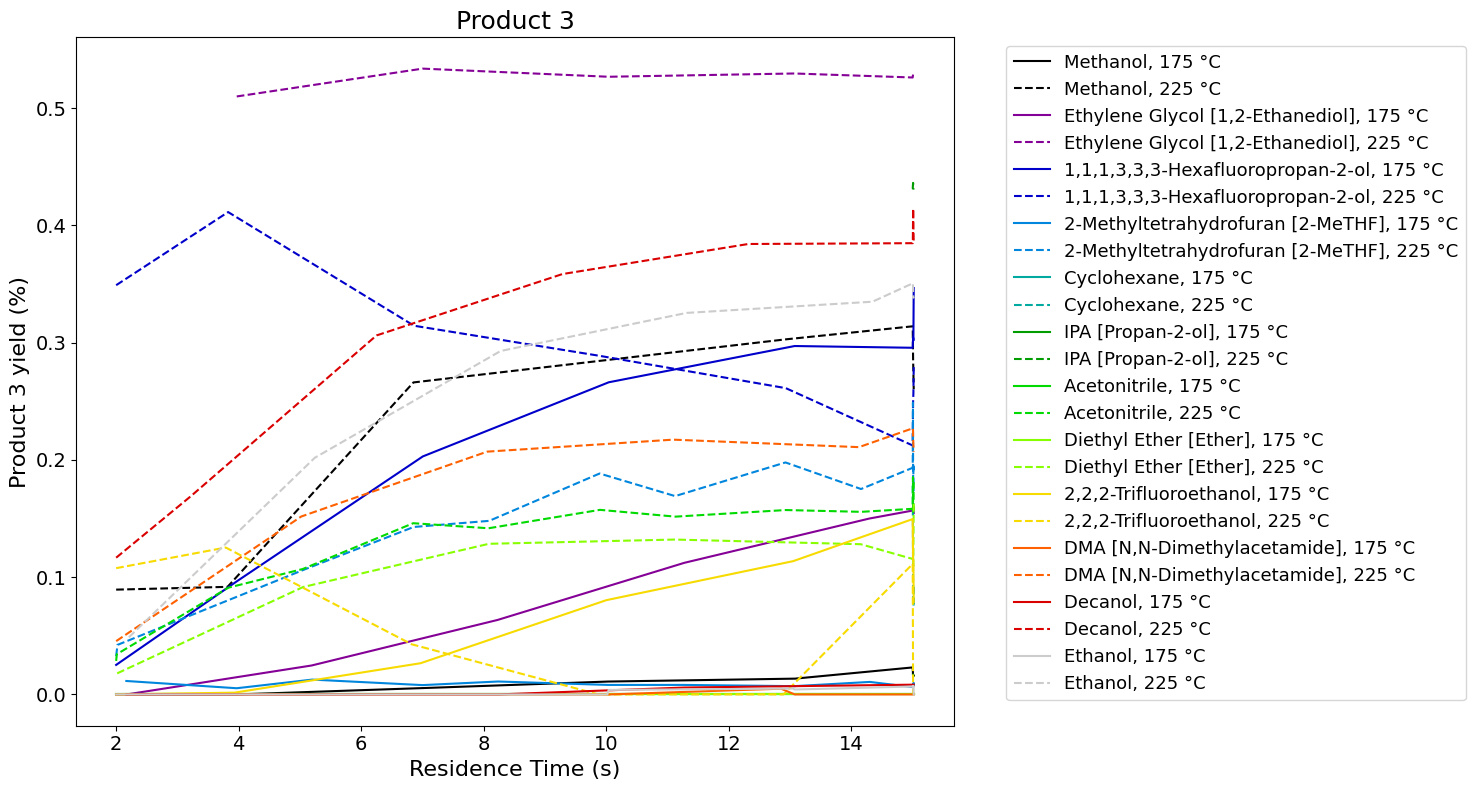

In [25]:
import matplotlib.lines as mlines

input_df, label_df = load_single_solvent_data()
input_df = spange_featurize_input_df(input_df)
train_inputs_df, train_labels_df, test_inputs_df, test_labels_df = train_test_split(input_df, label_df, train_percentage=0.7)

# --- Build EXP NUM -> (Temperature, SOLVENT NAME) mapping ---
exp_meta = (
    train_labels_df[["EXP NUM", "Temperature", "SOLVENT NAME"]]
    .drop_duplicates("EXP NUM")
    .set_index("EXP NUM")
)

# --- Assign colours per solvent, linestyles per temperature ---
unique_solvents = list(dict.fromkeys(exp_meta["SOLVENT NAME"]))
unique_temps = sorted(exp_meta["Temperature"].unique())

cmap = plt.cm.get_cmap("nipy_spectral", len(unique_solvents))
color_map = {s: cmap(i) for i, s in enumerate(unique_solvents)}

linestyles = ["-", "--", "-.", ":"]
linestyle_map = {t: linestyles[i % len(linestyles)] for i, t in enumerate(unique_temps)}

def plot_yield(train_labels_df, exp_meta, color_map, linestyle_map, column, ylabel, title):
    fig, ax = plt.subplots(figsize=(15, 8))
    legend_seen = set()
    legend_handles = []

    for exp_num, group in train_labels_df.groupby("EXP NUM", sort=False):
        solvent = exp_meta.loc[exp_num, "SOLVENT NAME"]
        temp = exp_meta.loc[exp_num, "Temperature"]
        color = color_map[solvent]
        ls = linestyle_map[temp]

        ax.plot(group["Residence Time"], group[column], color=color, linestyle=ls)

        key = (solvent, temp)
        if key not in legend_seen:
            legend_seen.add(key)
            legend_handles.append(
                mlines.Line2D([], [], color=color, linestyle=ls, label=f"{solvent}, {int(temp)} °C")
            )

    ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True, fontsize=13)
    ax.set_xlabel("Residence Time (s)", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis="both", labelsize=14)
    plt.tight_layout()
    plt.show()

plot_yield(train_labels_df, exp_meta, color_map, linestyle_map,
           "SM", "SM yield (%)", "Starting Material")

plot_yield(train_labels_df, exp_meta, color_map, linestyle_map,
           "Product 2", "Product 2 yield (%)", "Product 2")

plot_yield(train_labels_df, exp_meta, color_map, linestyle_map,
           "Product 3", "Product 3 yield (%)", "Product 3")


## 2. Optimise pyomo model using IPOPT (train the neural ODE) for single solvent ramp

In [26]:

# choose single solvent to train model on 
hexafluro_train_label_df = train_labels_df[
    (train_labels_df["EXP NUM"] == 4) &
    (train_labels_df["Temperature"] == 175)
]

hexafluro_train_inputs_df = train_inputs_df[
    (train_inputs_df["EXP NUM"] == 4) &
    (train_inputs_df["Temperature"] == 175)
]

print("hexafluro_train_label_df:")
display(hexafluro_train_label_df)

print("\nhexafluro_train_inputs_df:")
display(hexafluro_train_inputs_df)

T = hexafluro_train_label_df["Residence Time"].iloc[-1] - hexafluro_train_label_df["Residence Time"].iloc[0]
print(T)
Y_obs = hexafluro_train_label_df[["SM", "Product 2", "Product 3"]].values  # shape: (num_measurement_points, state_dim)
print(Y_obs.shape)
layer_sizes = [3, 32, 3] 
num_res_eval_nodes = 100

# Define solver option dictionary 
solver_options_dc = {
    "max_iter": 500,
    "nlp_scaling_method": "gradient-based",
    "mu_strategy": "adaptive",
    "tol": 1e-6,
    "acceptable_tol": 1e-5,
    "acceptable_iter": 10
}

solver_options_irrdc = {
    "max_iter": 1000,
    "nlp_scaling_method": "gradient-based",
    "mu_strategy": "adaptive",
    "tol": 1e-6,
    "acceptable_tol": 1e-5,
    "acceptable_iter": 10
} 

pyo_model_dc = NeuralODEPyomo(
    Y_obs, layer_sizes, T, 
    state_lower_bound=-100,
    state_upper_bound=100,
    param_lower_bound=-100,
    param_upper_bound=100,
    lambda_reg=1e-4, 
    Y_smooth=None, 
    transcription_method='dc'
)
pyo_model_dc.solve_model(solver_options_dc)

pyo_model_irrdc = NeuralODEPyomo(
    Y_obs, layer_sizes, T, 
    state_lower_bound=-100,
    state_upper_bound=100,
    param_lower_bound=-100,
    param_upper_bound=100,
    lambda_reg=1e-4, 
    Y_smooth=None, 
    transcription_method='irrdc',
    rho_reg=1,
    num_res_eval_nodes=num_res_eval_nodes
)
pyo_model_irrdc.solve_model(solver_options_irrdc)

hexafluro_train_label_df:


,EXP NUM,Residence Time,Temperature,SM,Product 2,Product 3,SOLVENT NAME
33,4,2.001019,175.0,0.957833,0.016929,0.025191,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
34,4,3.972851,175.0,0.832480,0.070948,0.096571,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
35,4,7.006481,175.0,0.579279,0.159725,0.203017,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
36,4,10.040260,175.0,0.395336,0.222791,0.266238,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
37,4,13.073911,175.0,0.333732,0.251590,0.297166,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
38,4,15.000545,175.0,0.356287,0.244024,0.295675,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
39,4,15.006821,175.0,0.316812,0.258240,0.304403,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
40,4,15.011738,175.0,0.325317,0.255309,0.301791,"1,1,1,3,3,3-Hexafluoropropan-2-ol"
41,4,15.017208,175.0,0.327276,0.277386,0.346614,"1,1,1,3,3,3-Hexafluoropropan-2-ol"



hexafluro_train_inputs_df:


,EXP NUM,Residence Time,Temperature,dielectric constant,ET(30),alpha,beta,pi*,SA,SB,SP,SdP,N,n,f(n),delta
33,4,2.001019,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
34,4,3.972851,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
35,4,7.006481,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
36,4,10.040260,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
37,4,13.073911,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
38,4,15.000545,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
39,4,15.006821,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
40,4,15.011738,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3
41,4,15.017208,175.0,16.7,62.1,1.96,0.0,0.65,1.011,0.014,0.499,1.454,0.0095,1.275,0.17256,19.3


13.016189304596537
(9, 3)
Solver available?: True
Ipopt 3.14.19: max_iter=500
nlp_scaling_method=gradient-based
mu_strategy=adaptive
print_level=5
tol=1e-06
acceptable_tol=1e-05
acceptable_iter=10


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:     4131
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     6230

Total number of variables............................:      254
                     variables with only lower bounds:        0
                variab

## 3. Use the trained model as RHS of an ODE system 

In [27]:
y0_train = Y_obs[0, :]
#y0_test = Y_test[0, :]
train_grid = hexafluro_train_label_df["Residence Time"].values

predicted_trajectory_train_irrdc = pyo_model_irrdc.get_predicted_trajectory(y0_train, train_grid, rtol=1e-7, atol=1e-9, max_step=(train_grid[1]-train_grid[0]))
#predicted_trajectory_test_irrdc = pyo_model_irrdc.get_predicted_trajectory(y0_test, test_grid, rtol=1e-7, atol=1e-9, max_step=(test_grid[1]-test_grid[0]))

predicted_trajectory_train_dc = pyo_model_dc.get_predicted_trajectory(y0_train, train_grid, rtol=1e-7, atol=1e-9, max_step=(train_grid[1]-train_grid[0]))
#predicted_trajectory_test_dc = pyo_model_dc.get_predicted_trajectory(y0_test, test_grid, rtol=1e-7, atol=1e-9, max_step=(test_grid[1]-test_grid[0]))

## 4. Plot predicted trajectories over train and test domains

IRR-DC: shape=(9, 3), NaN=False, Inf=False, min=0.0169, max=0.9578
DC: shape=(9, 3), NaN=False, Inf=False, min=0.0169, max=0.9578


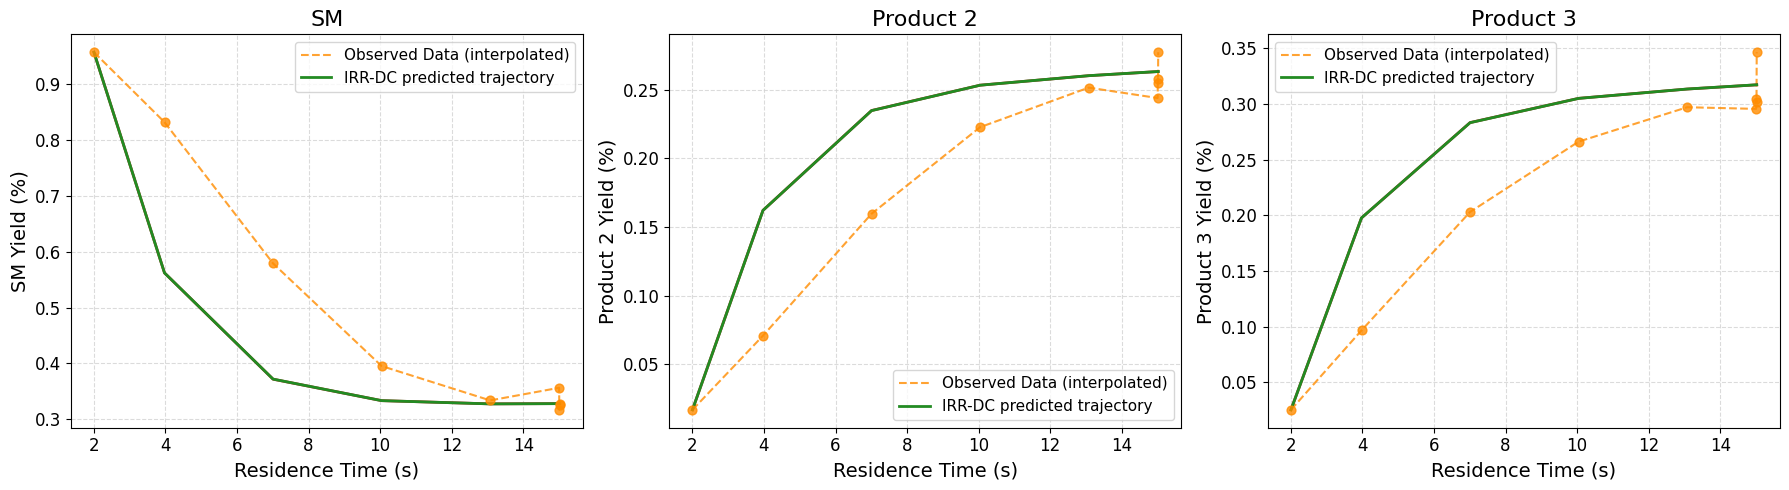

In [28]:
for label, traj in [("IRR-DC", predicted_trajectory_train_irrdc), ("DC", predicted_trajectory_train_dc)]:
    has_nan = np.any(np.isnan(traj))
    has_inf = np.any(np.isinf(traj))
    print(f"{label}: shape={traj.shape}, NaN={has_nan}, Inf={has_inf}, min={np.nanmin(traj):.4f}, max={np.nanmax(traj):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
state_names  = ["SM", "Product 2", "Product 3"]
state_labels = ["SM Yield (%)", "Product 2 Yield (%)", "Product 3 Yield (%)"]

for i, (name, ylabel) in enumerate(zip(state_names, state_labels)):
    ax = axes[i]

    # Linear interpolation of observed data
    ax.plot(train_grid, Y_obs[:, i], color='darkorange', linewidth=1.5,
            linestyle='--', alpha=0.8, label="Observed Data (interpolated)")

    # Observed (noisy) training data
    ax.scatter(train_grid, Y_obs[:, i], color='darkorange', marker='o', s=40,
               alpha=0.8, zorder=5)

    # Predicted trajectories — DC first so IRR-DC renders on top
    ax.plot(train_grid, predicted_trajectory_train_dc[:, i],
            color='firebrick', linewidth=2)
    ax.plot(train_grid, predicted_trajectory_train_irrdc[:, i],
            color='forestgreen', linewidth=2, label="IRR-DC predicted trajectory", zorder=4)

    ax.set_xlabel("Residence Time (s)", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(name, fontsize=16)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()
